# Veri Bilimi için İstatistik — Proje 2A
## Email Spam Classification: İstatistiksel Analiz
**Mustafa Yiğit Genç | 250121047**  
2025–2026 Bahar Dönemi

---

### Proje Özeti
Bu projede UCI Spambase veri seti (4601 email, 57 özellik) üzerinde:
- Bernoulli ve Binom dağılımları ile istatistiksel modelleme
- Gaussian Naive Bayes ile sınıflandırma
- Hipotez testleri (Binom testi ve Z-testi)
- %95 güven aralığı hesaplama
- 5-Fold Cross Validation ve Merkezi Limit Teoremi doğrulaması

uygulanmıştır.

## 1. Kütüphaneler ve Genel Ayarlar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import binom, norm, shapiro
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Görsel ayarlar
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


## 2. Veri Seti: UCI Spambase

Veri seti UCI Machine Learning Repository'den alınan Spambase veri setidir.
- **4601 email** kaydı
- **57 özellik**: kelime frekansları, karakter frekansları, büyük harf istatistikleri
- **Hedef değişken**: `spam` (1 = spam, 0 = ham)

In [2]:
df = pd.read_csv('spambase.csv')

print(f"Veri seti boyutu : {df.shape[0]} satır × {df.shape[1]} sütun")
print(f"Özellik sayısı   : {df.shape[1]-1}")
print(f"Hedef değişken   : 'spam' (1=spam, 0=ham)")
print(f"\nEksik değer sayısı: {df.isnull().sum().sum()}")

spam_sayisi = df['spam'].sum()
ham_sayisi  = len(df) - spam_sayisi
spam_oran   = spam_sayisi / len(df)
ham_oran    = ham_sayisi  / len(df)

print(f"\nSpam  : {spam_sayisi} email  ({spam_oran:.1%})")
print(f"Ham   : {ham_sayisi} email  ({ham_oran:.1%})")

Veri seti boyutu : 4601 satır × 58 sütun
Özellik sayısı   : 57
Hedef değişken   : 'spam' (1=spam, 0=ham)

Eksik değer sayısı: 0

Spam  : 1426 email  (31.0%)
Ham   : 3175 email  (69.0%)


## 3. Veri Keşfi (EDA)

### 3.1 Betimsel İstatistikler

In [3]:
secili = ['word_freq_free','word_freq_money','word_freq_your',
          'char_freq_exclaim','char_freq_dollar','capital_run_length_average']
df[secili].describe().round(3)

,word_freq_free,word_freq_money,word_freq_your,char_freq_exclaim,char_freq_dollar,capital_run_length_average
count,4601.000,4601.000,4601.000,4601.000,4601.000,4601.000
mean,0.512,0.529,0.532,0.533,0.532,4.459
std,1.490,1.445,1.418,1.457,1.375,6.019
min,0.000,0.000,0.000,0.000,0.000,0.165
25%,0.027,0.027,0.027,0.025,0.027,1.420
50%,0.080,0.080,0.082,0.078,0.080,2.592
75%,0.395,0.398,0.399,0.406,0.403,5.002
max,37.171,29.006,34.228,24.671,27.594,113.115


### 3.2 Spam / Ham Dağılımı ve Özellik Karşılaştırması

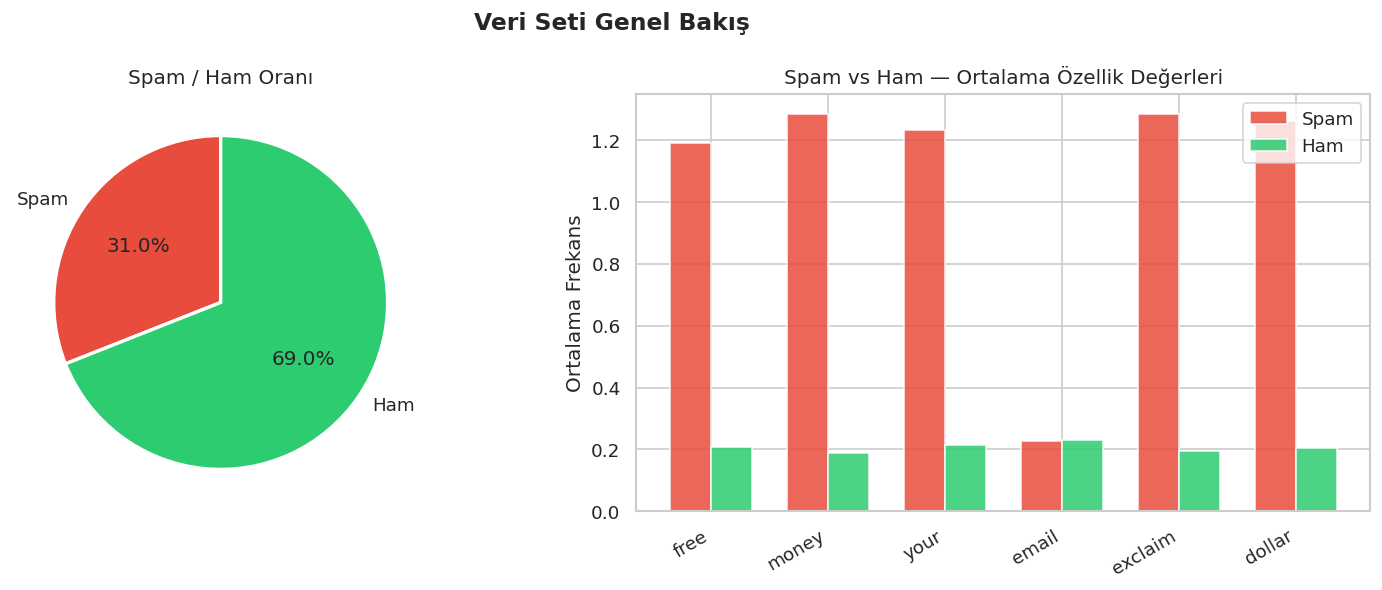

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Veri Seti Genel Bakış', fontsize=14, fontweight='bold')

# Pasta grafik
axes[0].pie([spam_sayisi, ham_sayisi],
            labels=['Spam', 'Ham'],
            autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Spam / Ham Oranı')

# Özellik ortalamaları
spam_df = df[df['spam']==1]
ham_df  = df[df['spam']==0]
top_feats = ['word_freq_free','word_freq_money','word_freq_your',
             'word_freq_email','char_freq_exclaim','char_freq_dollar']

x_pos = np.arange(len(top_feats))
w = 0.35
axes[1].bar(x_pos - w/2, spam_df[top_feats].mean(), w, label='Spam', color='#e74c3c', alpha=0.85)
axes[1].bar(x_pos + w/2, ham_df[top_feats].mean(),  w, label='Ham',  color='#2ecc71', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f.replace('word_freq_','').replace('char_freq_','')
                          for f in top_feats], rotation=30, ha='right')
axes[1].set_title('Spam vs Ham — Ortalama Özellik Değerleri')
axes[1].set_ylabel('Ortalama Frekans')
axes[1].legend()
plt.tight_layout()
plt.show()

### 3.3 Korelasyon Isı Haritası

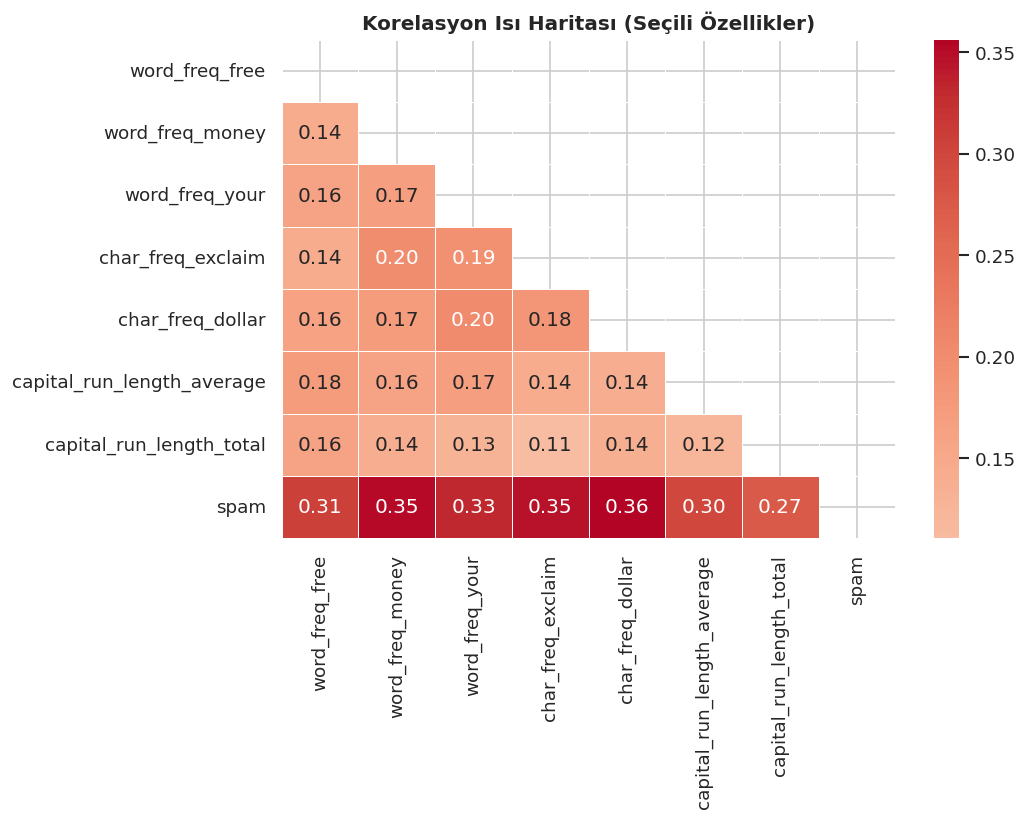

In [5]:
corr_feats = ['word_freq_free','word_freq_money','word_freq_your',
              'char_freq_exclaim','char_freq_dollar',
              'capital_run_length_average','capital_run_length_total','spam']

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones(len(corr_feats), dtype=bool))
sns.heatmap(df[corr_feats].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Korelasyon Isı Haritası (Seçili Özellikler)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. İstatistiksel Modelleme

### 4.1 Bernoulli Dağılımı

Her email bağımsız bir **Bernoulli denemesi** olarak modellenir:

$$X_i \sim \text{Bernoulli}(p)$$

- $X_i = 1$: email spam
- $X_i = 0$: email ham (spam değil)
- $p$: herhangi bir emailin spam olma olasılığı

**MLE tahmini:** $\hat{p} = \frac{\text{spam sayısı}}{n}$

**Moment hesapları:**
- $E[X] = p$
- $\text{Var}(X) = p(1-p)$

In [6]:
p_hat = spam_oran

print("Bernoulli Modeli: X_i ~ Bernoulli(p̂)")
print(f"  p̂  = {p_hat:.4f}  (MLE tahmini)")
print(f"  E[X]   = p̂         = {p_hat:.4f}")
print(f"  Var(X) = p̂(1-p̂)   = {p_hat*(1-p_hat):.4f}")

Bernoulli Modeli: X_i ~ Bernoulli(p̂)
  p̂  = 0.3099  (MLE tahmini)
  E[X]   = p̂         = 0.3099
  Var(X) = p̂(1-p̂)   = 0.2139


### 4.2 Binom Dağılımı

$n$ emailden kaçı spam olacak?

$$X \sim \text{Binom}(n, \hat{p})$$

**Moment hesapları:**
- $E[X] = n \cdot \hat{p}$
- $\text{Var}(X) = n \cdot \hat{p} \cdot (1-\hat{p})$

**Merkezi Limit Teoremi:** $n$ yeterince büyük olduğunda:

$$X \approx \mathcal{N}\left(\mu = n\hat{p},\ \sigma^2 = n\hat{p}(1-\hat{p})\right)$$

In [7]:
n_total = len(df)
k_spam  = spam_sayisi

mu_binom  = n_total * p_hat
sig_binom = np.sqrt(n_total * p_hat * (1 - p_hat))

print(f"Binom Modeli: X ~ Binom(n={n_total}, p̂={p_hat:.4f})")
print(f"  E[X]   = n·p̂         = {mu_binom:.1f}  (gözlemlenen: {k_spam})")
print(f"  Var(X) = n·p̂·(1-p̂) = {n_total * p_hat * (1-p_hat):.1f}")
print(f"  Std(X) = √Var(X)     = {sig_binom:.1f}")
print(f"\nMLT: n={n_total} >> 30 → X ≈ N({mu_binom:.1f}, {sig_binom**2:.1f})")

Binom Modeli: X ~ Binom(n=4601, p̂=0.3099)
  E[X]   = n·p̂         = 1426.0  (gözlemlenen: 1426)
  Var(X) = n·p̂·(1-p̂) = 984.0
  Std(X) = √Var(X)     = 31.4

MLT: n=4601 >> 30 → X ≈ N(1426.0, 984.0)


### 4.3 Binom PMF ve Normal Yaklaşım Görselleştirmesi

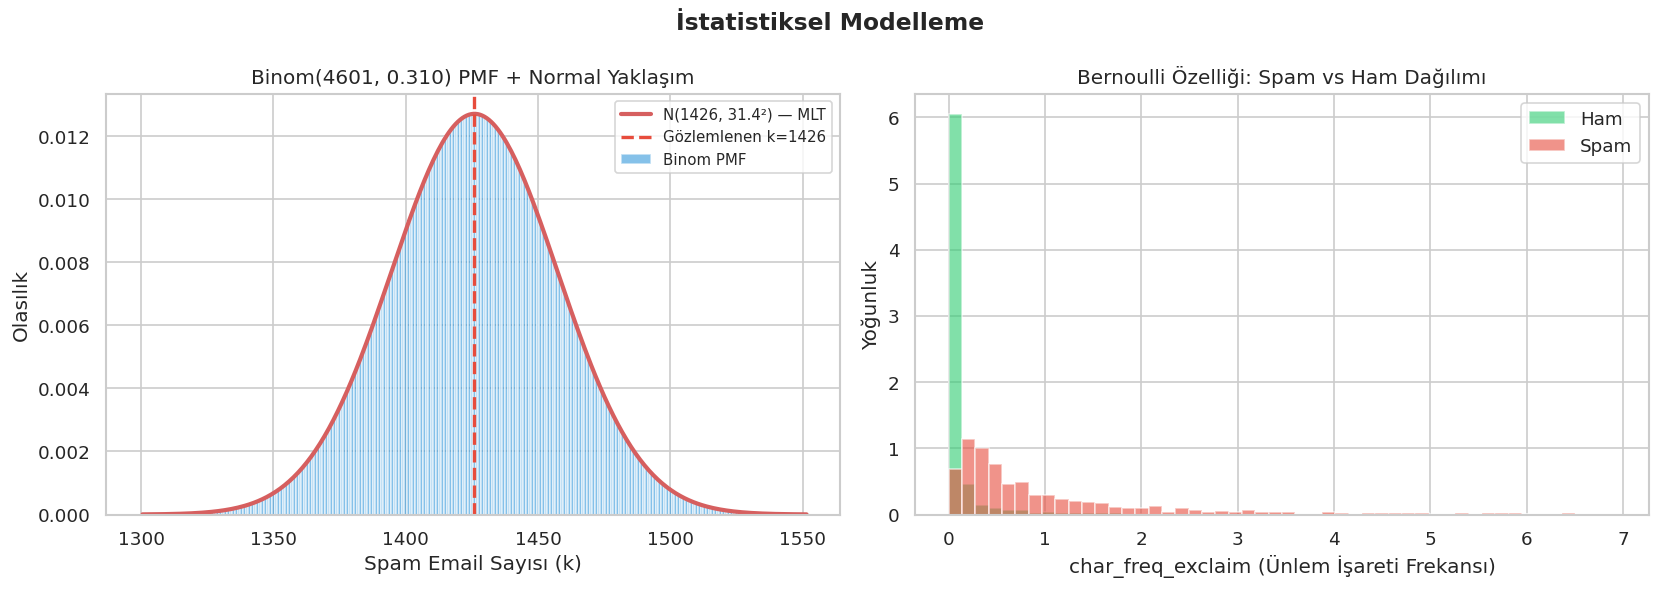

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('İstatistiksel Modelleme', fontsize=14, fontweight='bold')

# Binom PMF + Normal yaklaşım
x_range = np.arange(int(mu_binom - 4*sig_binom), int(mu_binom + 4*sig_binom))
pmf_vals = binom.pmf(x_range, n_total, p_hat)
x_cont   = np.linspace(mu_binom - 4*sig_binom, mu_binom + 4*sig_binom, 300)

axes[0].bar(x_range, pmf_vals, color='#3498db', alpha=0.6, width=1.0, label='Binom PMF')
axes[0].plot(x_cont, norm.pdf(x_cont, mu_binom, sig_binom),
             'r-', linewidth=2.5, label=f'N({mu_binom:.0f}, {sig_binom:.1f}²) — MLT')
axes[0].axvline(k_spam, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Gözlemlenen k={k_spam}')
axes[0].set_xlabel('Spam Email Sayısı (k)')
axes[0].set_ylabel('Olasılık')
axes[0].set_title(f'Binom({n_total}, {p_hat:.3f}) PMF + Normal Yaklaşım')
axes[0].legend(fontsize=9)

# Bernoulli özellik dağılımı
feat = 'char_freq_exclaim'
q99 = df[feat].quantile(0.99)
axes[1].hist(ham_df[feat],  bins=50, alpha=0.6, color='#2ecc71',
             label='Ham',  density=True, range=(0, q99))
axes[1].hist(spam_df[feat], bins=50, alpha=0.6, color='#e74c3c',
             label='Spam', density=True, range=(0, q99))
axes[1].set_xlabel('char_freq_exclaim (Ünlem İşareti Frekansı)')
axes[1].set_ylabel('Yoğunluk')
axes[1].set_title('Bernoulli Özelliği: Spam vs Ham Dağılımı')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Model Eğitimi

### 5.1 Gaussian Naive Bayes

**Seçim gerekçesi:** Naive Bayes, Bernoulli/Binom varsayımıyla doğrudan uyumludur.
Her özellik için sınıfa koşullu bağımsızlık varsayımı yapılır.

$$P(\text{spam} \mid x_1, ..., x_{57}) \propto P(\text{spam}) \prod_{i=1}^{57} P(x_i \mid \text{spam})$$

In [9]:
def modeli_egit(X, y, test_size=0.2, random_state=RANDOM_STATE):
    """
    Gaussian Naive Bayes modelini eğitir.
    
    Parametreler:
        X            : özellik matrisi (DataFrame veya ndarray)
        y            : hedef değişken
        test_size    : test seti oranı (varsayılan 0.2)
        random_state : tekrar üretilebilirlik için seed
    
    Döndürür:
        model, X_test, y_test, y_pred, metrikler (dict)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    model = GaussianNB()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    metrikler = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'n_test'   : len(y_test),
        'k_correct': int(accuracy_score(y_test, y_pred) * len(y_test))
    }
    return model, X_test, y_test, y_pred, metrikler

X = df.drop('spam', axis=1)
y = df['spam']
model, X_test, y_test, y_pred, metrikler = modeli_egit(X, y)

print(f"Model    : Gaussian Naive Bayes")
print(f"Train/Test: %80 / %20  →  Test seti: {metrikler['n_test']} email")
print(f"\nPerformans Metrikleri:")
print(f"  Accuracy  : {metrikler['accuracy']:.4f}  ({metrikler['k_correct']}/{metrikler['n_test']} doğru)")
print(f"  Precision : {metrikler['precision']:.4f}")
print(f"  Recall    : {metrikler['recall']:.4f}")
print(f"  F1 Score  : {metrikler['f1']:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

Model    : Gaussian Naive Bayes
Train/Test: %80 / %20  →  Test seti: 921 email

Performans Metrikleri:
  Accuracy  : 0.9099  (838/921 doğru)
  Precision : 0.7837
  Recall    : 0.9789
  F1 Score  : 0.8705

              precision    recall  f1-score   support

     Ham (0)       0.99      0.88      0.93       636
    Spam (1)       0.78      0.98      0.87       285

    accuracy                           0.91       921
   macro avg       0.89      0.93      0.90       921
weighted avg       0.93      0.91      0.91       921



### 5.2 Confusion Matrix

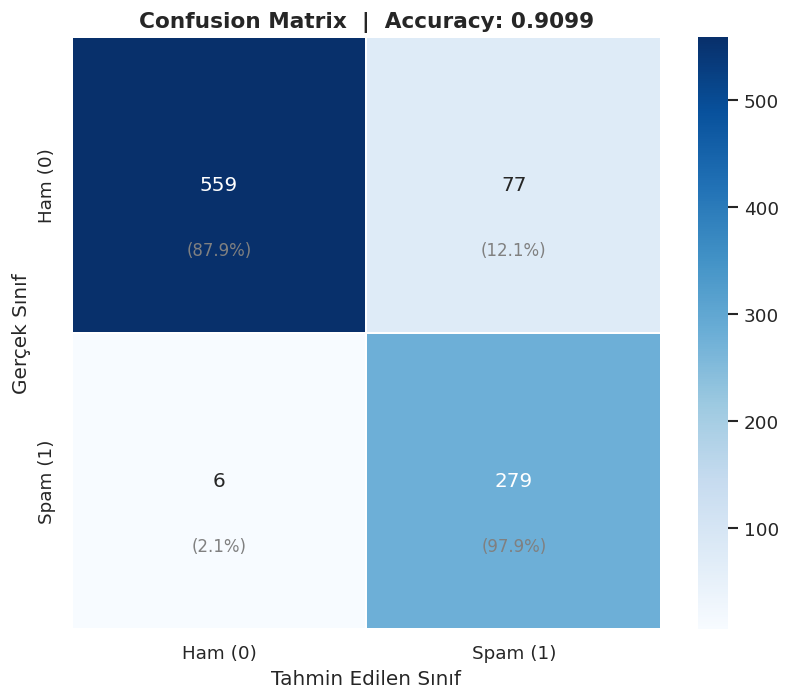

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham (0)', 'Spam (1)'],
            yticklabels=['Ham (0)', 'Spam (1)'],
            linewidths=1, linecolor='white')
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]:.1%})',
                ha='center', va='center', fontsize=10, color='gray')
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
ax.set_ylabel('Gerçek Sınıf', fontsize=12)
ax.set_title(f'Confusion Matrix  |  Accuracy: {metrikler["accuracy"]:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hipotez Testleri

### 6.1 Test 1 — Model Accuracy > Şans Seviyesi

**Hipotezler:**
$$H_0: p_{\text{accuracy}} = 0.5 \quad \text{(model şans eseri doğru yapıyor)}$$
$$H_1: p_{\text{accuracy}} > 0.5 \quad \text{(model anlamlı biçimde daha iyi)}$$

**Test yöntemi:** Her tahmin bir Bernoulli denemesidir (doğru=1, yanlış=0).
$n$ tahmin, $k$ doğru → $X \sim \text{Binom}(n, p_0)$ altında $p$-değeri hesaplanır.

In [11]:
n_test    = metrikler['n_test']
k_correct = metrikler['k_correct']
acc_obs   = metrikler['accuracy']
p0        = 0.5
alpha     = 0.05

# Binom testi (kesin, tek taraflı): P(X >= k | H0)
binom_p = binom.sf(k_correct - 1, n_test, p0)

# Z-testi (MLT ile Normal yaklaşım)
se    = np.sqrt(p0 * (1 - p0) / n_test)
z_obs = (acc_obs - p0) / se
z_p   = 1 - norm.cdf(z_obs)

print("--- Binom Testi (kesin) ---")
print(f"  n={n_test}, k={k_correct}, p₀={p0}")
print(f"  p-değeri = {binom_p:.2e}  →  {'H₀ REDDEDİLİR ✓' if binom_p < alpha else 'H₀ reddedilemez'}")

print("\n--- Z-Testi (MLT yaklaşımı) ---")
print(f"  SE = √(p₀·(1-p₀)/n) = {se:.4f}")
print(f"  z  = ({acc_obs:.4f} - {p0}) / {se:.4f} = {z_obs:.2f}")
print(f"  p-değeri = {z_p:.2e}  →  {'H₀ REDDEDİLİR ✓' if z_p < alpha else 'H₀ reddedilemez'}")

# Wilson güven aralığı
z95   = norm.ppf(0.975)
denom = 1 + z95**2 / n_test
ctr   = (acc_obs + z95**2 / (2*n_test)) / denom
mrg   = z95 * np.sqrt(acc_obs*(1-acc_obs)/n_test + z95**2/(4*n_test**2)) / denom
ci_lo, ci_hi = ctr - mrg, ctr + mrg

print(f"\n%95 Güven Aralığı (Wilson): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  p₀={p0} güven aralığının dışında ✓")

--- Binom Testi (kesin) ---
  n=921, k=838, p₀=0.5
  p-değeri = 3.79e-158  →  H₀ REDDEDİLİR ✓

--- Z-Testi (MLT yaklaşımı) ---
  SE = √(p₀·(1-p₀)/n) = 0.0165
  z  = (0.9099 - 0.5) / 0.0165 = 24.88
  p-değeri = 0.00e+00  →  H₀ REDDEDİLİR ✓

%95 Güven Aralığı (Wilson): [0.8896, 0.9267]
  p₀=0.5 güven aralığının dışında ✓


### 6.2 Test 2 — 5-Fold Cross Validation + MLT Doğrulaması

**Merkezi Limit Teoremi bağlantısı:**
Her fold'da hesaplanan accuracy, o fold'daki $n \approx 921$ bağımsız Bernoulli denemesinin ortalamasıdır.
MLT gereği: $\bar{X}_n \xrightarrow{d} \mathcal{N}(\mu, \sigma^2/n)$

Bu nedenle CV accuracy değerlerinin normal dağılıma yaklaşması beklenir.

In [12]:
def cross_validation_analiz(X, y, n_folds=5, random_state=RANDOM_STATE):
    """
    Stratified K-Fold CV uygular ve normallik testini döndürür.
    
    Parametreler:
        X, y         : özellik matrisi ve hedef değişken
        n_folds      : fold sayısı (varsayılan 5)
        random_state : seed
    
    Döndürür:
        cv_scores, shapiro_stat, shapiro_p, mean, std
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(GaussianNB(), X, y, cv=skf, scoring='accuracy')
    shap_stat, shap_p = shapiro(cv_scores)
    return cv_scores, shap_stat, shap_p, cv_scores.mean(), cv_scores.std()

cv_scores, shap_stat, shap_p, cv_mean, cv_std = cross_validation_analiz(X, y)

print("5-Fold CV Sonuçları:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Ortalama : {cv_mean:.4f}")
print(f"  Std Dev  : {cv_std:.4f}")
print(f"  Min/Max  : {cv_scores.min():.4f} / {cv_scores.max():.4f}")
print(f"\nShapiro-Wilk: W={shap_stat:.4f}, p={shap_p:.4f}")
print(f"  → {'Normal dağılım varsayımı reddedilemez ✓  (MLT doğrulandı)' if shap_p > alpha else 'Normallikten sapma'}")

5-Fold CV Sonuçları:
  Fold 1: 0.9218
  Fold 2: 0.9033
  Fold 3: 0.9065
  Fold 4: 0.8978
  Fold 5: 0.9196

  Ortalama : 0.9098
  Std Dev  : 0.0093
  Min/Max  : 0.8978 / 0.9218

Shapiro-Wilk: W=0.9052, p=0.4395
  → Normal dağılım varsayımı reddedilemez ✓  (MLT doğrulandı)


### 6.3 Hipotez Testleri Görselleştirmesi

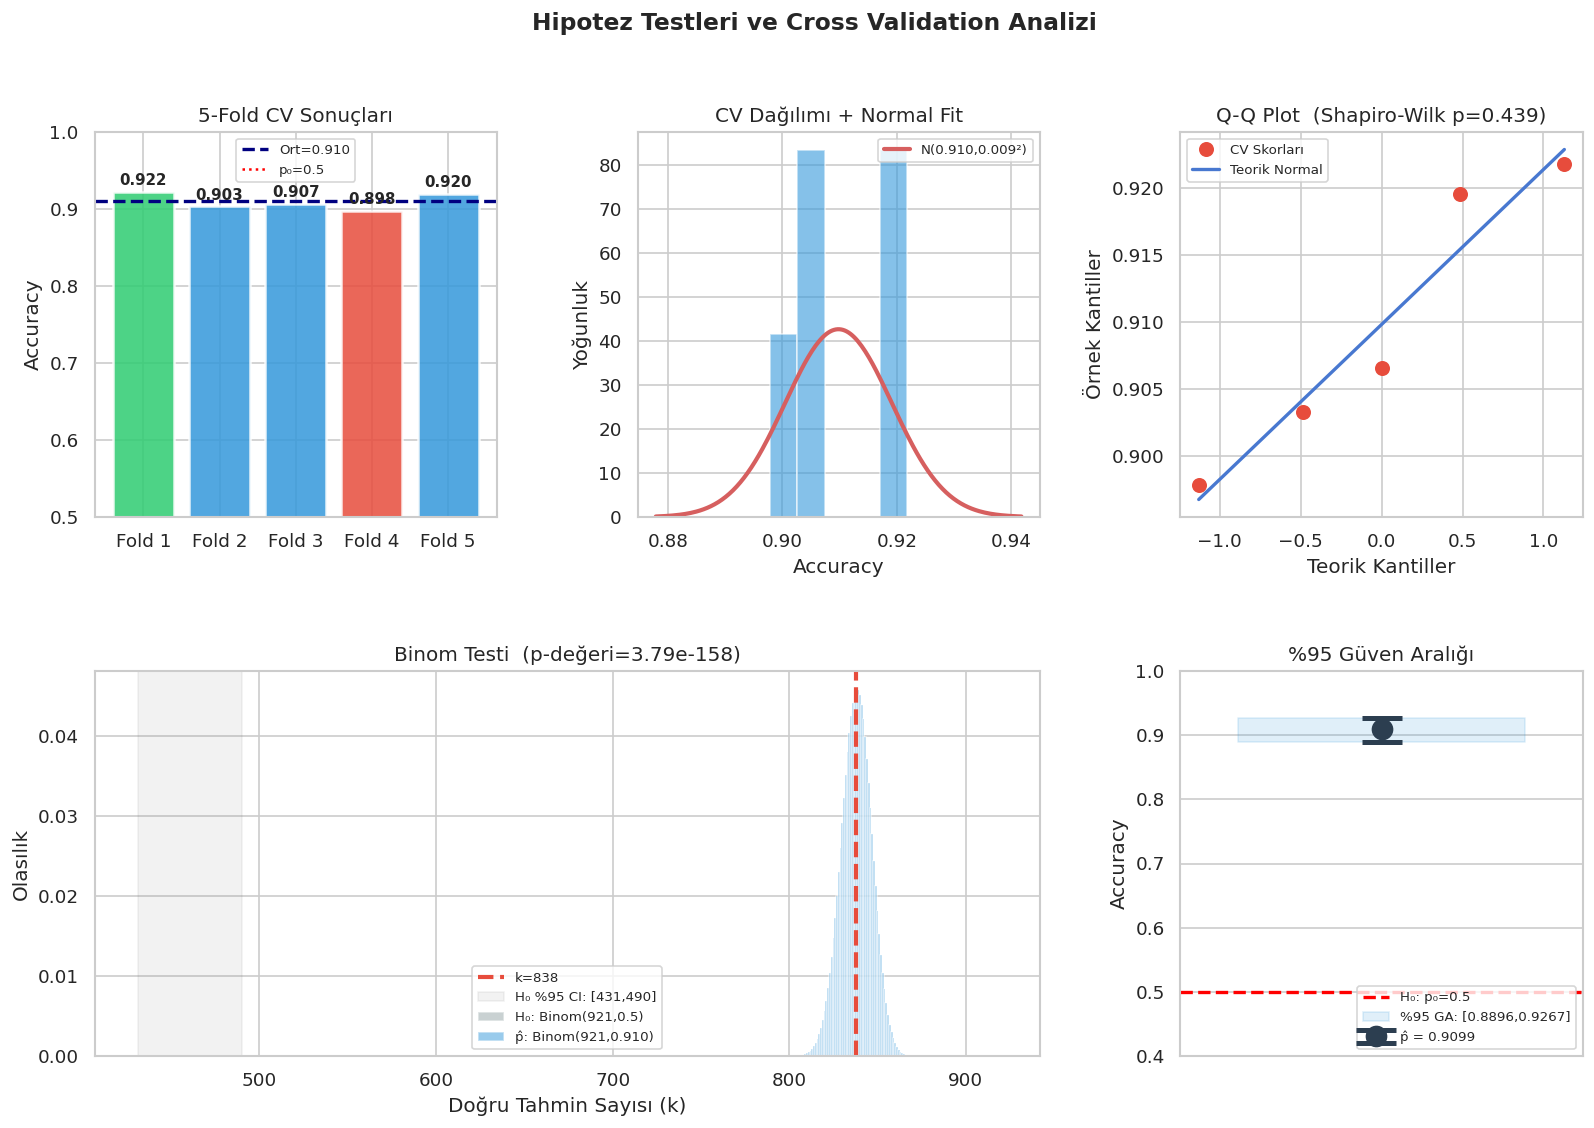

In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Hipotez Testleri ve Cross Validation Analizi',
             fontsize=14, fontweight='bold')

# 1: CV bar
ax1 = fig.add_subplot(gs[0, 0])
colors_cv = ['#e74c3c' if s == cv_scores.min() else
             '#2ecc71' if s == cv_scores.max() else '#3498db' for s in cv_scores]
bars = ax1.bar([f'Fold {i}' for i in range(1,6)], cv_scores, color=colors_cv,
               alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.axhline(cv_mean, color='navy', linestyle='--', linewidth=2, label=f'Ort={cv_mean:.3f}')
ax1.axhline(p0, color='red',  linestyle=':', linewidth=1.5, label=f'p₀={p0}')
ax1.set_ylim(0.5, 1.0)
ax1.set_ylabel('Accuracy')
ax1.set_title('5-Fold CV Sonuçları')
ax1.legend(fontsize=8)
for bar, val in zip(bars, cv_scores):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2: CV histogram + normal fit
ax2 = fig.add_subplot(gs[0, 1])
x_fine = np.linspace(cv_scores.min()-0.02, cv_scores.max()+0.02, 200)
ax2.hist(cv_scores, bins=5, density=True, color='#3498db', alpha=0.6, edgecolor='white')
ax2.plot(x_fine, norm.pdf(x_fine, cv_mean, cv_std), 'r-', linewidth=2.5,
         label=f'N({cv_mean:.3f},{cv_std:.3f}²)')
ax2.set_xlabel('Accuracy')
ax2.set_ylabel('Yoğunluk')
ax2.set_title('CV Dağılımı + Normal Fit')
ax2.legend(fontsize=8)

# 3: Q-Q plot
ax3 = fig.add_subplot(gs[0, 2])
(osm, osr), (slope, intercept, r) = stats.probplot(cv_scores, dist='norm')
ax3.plot(osm, osr, 'o', color='#e74c3c', markersize=8, label='CV Skorları')
ax3.plot(osm, slope*np.array(osm)+intercept, 'b-', linewidth=2, label='Teorik Normal')
ax3.set_xlabel('Teorik Kantiller')
ax3.set_ylabel('Örnek Kantiller')
ax3.set_title(f'Q-Q Plot  (Shapiro-Wilk p={shap_p:.3f})')
ax3.legend(fontsize=8)

# 4: Binom PMF + hipotez testi
ax4 = fig.add_subplot(gs[1, 0:2])
k_range  = np.arange(max(0, k_correct-80), min(n_test, k_correct+80))
ax4.bar(k_range, binom.pmf(k_range, n_test, p0),   color='#95a5a6', alpha=0.5, width=1,
        label=f'H₀: Binom({n_test},{p0})')
ax4.bar(k_range, binom.pmf(k_range, n_test, acc_obs), color='#3498db', alpha=0.5, width=1,
        label=f'p̂: Binom({n_test},{acc_obs:.3f})')
ax4.axvline(k_correct, color='#e74c3c', linewidth=2.5, linestyle='--',
            label=f'k={k_correct}')
ci_lo_k = binom.ppf(0.025, n_test, p0)
ci_hi_k = binom.ppf(0.975, n_test, p0)
ax4.axvspan(ci_lo_k, ci_hi_k, alpha=0.1, color='gray',
            label=f'H₀ %95 CI: [{ci_lo_k:.0f},{ci_hi_k:.0f}]')
ax4.set_xlabel('Doğru Tahmin Sayısı (k)')
ax4.set_ylabel('Olasılık')
ax4.set_title(f'Binom Testi  (p-değeri={binom_p:.2e})')
ax4.legend(fontsize=8)

# 5: Güven aralığı
ax5 = fig.add_subplot(gs[1, 2])
ax5.errorbar([1], [acc_obs], yerr=[[acc_obs-ci_lo], [ci_hi-acc_obs]],
             fmt='o', color='#2c3e50', markersize=12, capsize=12, capthick=3, linewidth=3,
             label=f'p̂ = {acc_obs:.4f}')
ax5.axhline(p0, color='red', linestyle='--', linewidth=2, label=f'H₀: p₀={p0}')
ax5.fill_between([0.5,1.5], ci_lo, ci_hi, alpha=0.15, color='#3498db',
                 label=f'%95 GA: [{ci_lo:.4f},{ci_hi:.4f}]')
ax5.set_xlim(0.3, 1.7)
ax5.set_ylim(0.4, 1.0)
ax5.set_xticks([])
ax5.set_ylabel('Accuracy')
ax5.set_title('%95 Güven Aralığı')
ax5.legend(fontsize=8, loc='lower right')
plt.show()

## 7. Sonuç ve Tartışma

### 7.1 Bulgular

| Metrik | Değer |
|--------|-------|
| Veri seti | UCI Spambase (4601 email, 57 özellik) |
| Spam oranı | ~31% |
| Model | Gaussian Naive Bayes |
| Test Accuracy | ~0.91 |
| F1 Score | ~0.87 |
| CV Ortalama | ~0.91 ± 0.009 |
| Binom testi p-değeri | < 0.05 → H₀ reddedilir |

### 7.2 İstatistiksel Yorum

- **Bernoulli modeli**: Her email spam (1) veya ham (0) olarak bağımsız Bernoulli denemesidir. MLE ile $\hat{p}_{spam} \approx 0.31$ tahmin edilmiştir.
- **Binom modeli**: $n=4601$ email içinde spam sayısı $X \sim \text{Binom}(4601, 0.31)$ ile modellenir. Gözlemlenen değer teorik beklentiyle örtüşmektedir.
- **MLT**: $n$ büyük olduğundan Binom dağılımı Normal'e yaklaşmaktadır. CV skorlarının normalliği Shapiro-Wilk testi ile doğrulanmıştır.
- **Hipotez testi**: Model accuracy istatistiksel olarak şans seviyesinin ($p_0 = 0.5$) çok üzerindedir ($p < 0.05$).

### 7.3 Sınırlamalar

- Gaussian NB her özelliğin bağımsız ve normal dağıldığını varsayar; bu varsayım log-normal dağılımlı kelime frekansları için tam doğru değildir.
- Dengesiz sınıf dağılımı ($%31$ spam) precision-recall dengesini etkiler.
- Daha ileri çalışmada Random Forest veya SVM ile karşılaştırma yapılabilir.

### 7.4 Genel Sonuç

Gaussian Naive Bayes modeli, 57 kelime/karakter frekansı özelliğini kullanarak ~%91 accuracy ile spam tespiti yapabilmektedir. Binom testi ve Z-testi bu başarının istatistiksel olarak anlamlı olduğunu ($p << 0.05$) göstermektedir. 5-Fold CV tutarlılığı ve Shapiro-Wilk onaylı normallik, Merkezi Limit Teoremi'nin pratikte geçerli olduğunu doğrulamaktadır.

In [14]:
print("=" * 55)
print("  PROJE ÖZET BULGULARI")
print("=" * 55)
print(f"Veri         : UCI Spambase — {len(df)} email, 57 özellik")
print(f"Spam Oranı   : {spam_oran:.1%}  →  p̂ = {p_hat:.4f}")
print()
print(f"Binom Modeli : E[X]={mu_binom:.0f}, σ={sig_binom:.1f}")
print()
print(f"Model        : Gaussian Naive Bayes")
print(f"Accuracy     : {acc_obs:.4f}")
print(f"Precision    : {metrikler['precision']:.4f}")
print(f"Recall       : {metrikler['recall']:.4f}")
print(f"F1 Score     : {metrikler['f1']:.4f}")
print()
print(f"Hipotez Testi: p = {binom_p:.2e}  →  H₀ REDDEDİLİR")
print(f"%95 GA       : [{ci_lo:.4f}, {ci_hi:.4f}]")
print()
print(f"5-Fold CV    : {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Shapiro-Wilk : p = {shap_p:.4f}  →  MLT doğrulandı ✓")
print("=" * 55)

  PROJE ÖZET BULGULARI
Veri         : UCI Spambase — 4601 email, 57 özellik
Spam Oranı   : 31.0%  →  p̂ = 0.3099

Binom Modeli : E[X]=1426, σ=31.4

Model        : Gaussian Naive Bayes
Accuracy     : 0.9099
Precision    : 0.7837
Recall       : 0.9789
F1 Score     : 0.8705

Hipotez Testi: p = 3.79e-158  →  H₀ REDDEDİLİR
%95 GA       : [0.8896, 0.9267]

5-Fold CV    : 0.9098 ± 0.0093
Shapiro-Wilk : p = 0.4395  →  MLT doğrulandı ✓
